In [6]:
import sympy as sp

# Define symbols
E, Jx, k, a, eps_s, eps_p = sp.symbols('E J_x k a epsilon_s epsilon_p')

# Construct the matrix
M = sp.Matrix([[eps_s - E, -2 * sp.I * Jx * sp.sin(k * a / 2)],
               [2 * sp.I * Jx * sp.sin(k * a / 2), eps_p - E]])

# Compute the determinant
det = M.det()

# Solve for E
roots = sp.solve(det, E)

# Simplify and print each root in LaTeX
for root in roots:
    simplified_root = sp.simplify(root)
    print(sp.latex(simplified_root))


\frac{\epsilon_{p}}{2} + \frac{\epsilon_{s}}{2} - \frac{\sqrt{16 J_{x}^{2} \sin^{2}{\left(\frac{a k}{2} \right)} + \epsilon_{p}^{2} - 2 \epsilon_{p} \epsilon_{s} + \epsilon_{s}^{2}}}{2}
\frac{\epsilon_{p}}{2} + \frac{\epsilon_{s}}{2} + \frac{\sqrt{16 J_{x}^{2} \sin^{2}{\left(\frac{a k}{2} \right)} + \epsilon_{p}^{2} - 2 \epsilon_{p} \epsilon_{s} + \epsilon_{s}^{2}}}{2}


AttributeError: 'list' object has no attribute 'replace'

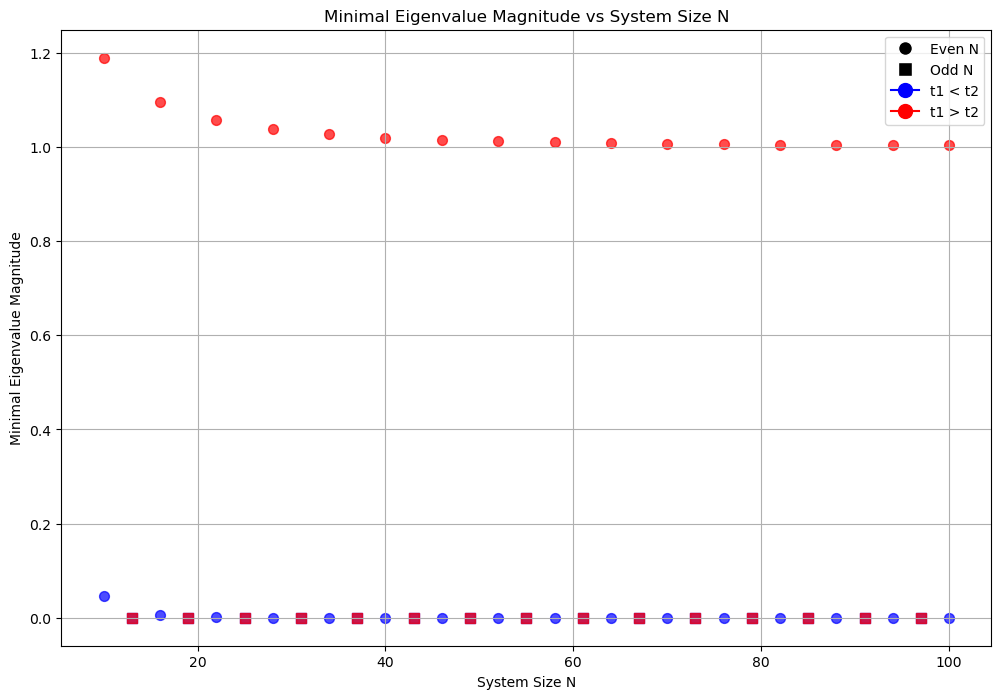

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # For custom legend entries

def construct_hamiltonian(t1, t2, N):
    if N == 0:
        return np.array([[]])  # Return an empty array for N=0
    H = np.zeros((N, N))
    for i in range(N - 1):
        if i % 2 == 0:
            H[i, i + 1] = t1
            H[i + 1, i] = t1
        else:
            H[i, i + 1] = t2
            H[i + 1, i] = t2
    return H

# Define the parameters for the SSH model
N_values = np.arange(10, 101, 3)  # N from 10 to 100, step 2
t_values = [(1.0, 2.0), (2.0, 1.0)]  # Two cases for t1 and t2

# Prepare lists to store data for plotting
N_list = []
min_eigenvalues = []
parity_list = []
t_order_list = []

for N in N_values:
    for t1, t2 in t_values:
        H = construct_hamiltonian(t1, t2, N)
        if H.size == 0:
            continue  # Skip empty Hamiltonians
        e_vals, e_vecs = np.linalg.eigh(H)
        # Store the minimal eigenvalue magnitude and corresponding data
        min_eig = np.min(np.abs(e_vals))
        N_list.append(N)
        min_eigenvalues.append(min_eig)
        parity_list.append(N % 2)  # 0 for even, 1 for odd
        t_order_list.append(0 if t1 < t2 else 1)  # 0 if t1 < t2, 1 if t1 > t2

# Start plotting
plt.figure(figsize=(12, 8))

# Define marker shapes for odd and even N
marker_shapes = {0: 'o', 1: 's'}  # Even N: circle, Odd N: square

# Define colors based on t1 and t2
color_map = {0: 'blue', 1: 'red'}  # t1 < t2: blue, t1 > t2: red

# Plot data
for i in range(len(N_list)):
    N = N_list[i]
    min_eig = min_eigenvalues[i]
    parity = parity_list[i]
    t_order = t_order_list[i]
    marker_shape = marker_shapes[parity]
    color = color_map[t_order]
    marker_size = 50  # You can adjust this value
    plt.scatter(N, min_eig, marker=marker_shape, color=color,
                s=marker_size, alpha=0.7)

plt.xlabel('System Size N')
plt.ylabel('Minimal Eigenvalue Magnitude')
plt.title('Minimal Eigenvalue Magnitude vs System Size N')
plt.grid(True)

# Create a custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Even N', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Odd N', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='blue', label='t1 < t2', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='red', label='t1 > t2', markerfacecolor='red', markersize=10),
]

plt.legend(handles=legend_elements, loc='upper right')
plt.show()
